In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/mrinalpandey2/theta-beta/theta_beta_master.csv


# ============================================================
# EEG Feature Redundancy Analysis
# Determines whether Theta & Beta add information beyond TBR
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from statsmodels.stats.outliers_influence import variance_inflation_factor


# ------------------------------------------------------------
# Load Dataset
# ------------------------------------------------------------

df = pd.read_csv("/kaggle/input/datasets/mrinalpandey2/theta-beta/theta_beta_master.csv")

# Change these names if your CSV differs
features = ["theta", "beta", "theta_beta_ratio"]

X = df[features].copy()

print("="*70)
print("Dataset Shape:", X.shape)
print("="*70)

# ------------------------------------------------------------
# Basic Statistics
# ------------------------------------------------------------

print("\nDESCRIPTIVE STATISTICS")
print(X.describe())

# ------------------------------------------------------------
# Pearson Correlation
# ------------------------------------------------------------

pearson_corr = X.corr(method="pearson")

print("\nPEARSON CORRELATION")
print(pearson_corr)

plt.figure(figsize=(6,5))
sns.heatmap(
    pearson_corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    square=True
)
plt.title("Pearson Correlation")
plt.show()

# ------------------------------------------------------------
# Spearman Correlation
# ------------------------------------------------------------

spearman_corr = X.corr(method="spearman")

print("\nSPEARMAN CORRELATION")
print(spearman_corr)

plt.figure(figsize=(6,5))
sns.heatmap(
    spearman_corr,
    annot=True,
    cmap="viridis",
    fmt=".2f",
    square=True
)
plt.title("Spearman Correlation")
plt.show()

# ------------------------------------------------------------
# Pairplot
# ------------------------------------------------------------

sns.pairplot(X)
plt.show()

# ------------------------------------------------------------
# Variance Inflation Factor
# ------------------------------------------------------------

print("\nVARIANCE INFLATION FACTOR")

X_vif = StandardScaler().fit_transform(X)

vif = pd.DataFrame()
vif["Feature"] = features
vif["VIF"] = [
    variance_inflation_factor(X_vif, i)
    for i in range(X_vif.shape[1])
]

print(vif)

# ------------------------------------------------------------
# PCA
# ------------------------------------------------------------

X_scaled = StandardScaler().fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained = pd.DataFrame({
    "Principal Component": [f"PC{i+1}" for i in range(len(features))],
    "Explained Variance": pca.explained_variance_ratio_,
    "Cumulative Variance": np.cumsum(pca.explained_variance_ratio_)
})

print("\nPCA EXPLAINED VARIANCE")
print(explained)

# ------------------------------------------------------------
# PCA Loadings
# ------------------------------------------------------------

loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(len(features))],
    index=features
)

print("\nPCA LOADINGS")
print(loadings)

# ------------------------------------------------------------
# Scree Plot
# ------------------------------------------------------------

plt.figure(figsize=(6,4))
plt.plot(
    range(1, len(features)+1),
    pca.explained_variance_ratio_,
    marker="o"
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("PCA Scree Plot")
plt.grid(True)
plt.show()

# ------------------------------------------------------------
# Decision Summary
# ------------------------------------------------------------

print("\n" + "="*70)
print("INTERPRETATION GUIDE")
print("="*70)

print("""
1. Correlation
   > |r| > 0.80  → Strong redundancy
   > |r| < 0.50  → Independent information

2. VIF
   < 5    → Acceptable
   5–10   → Moderate multicollinearity
   >10    → Severe multicollinearity

3. PCA
   If PC1 explains >90% variance,
   one latent feature captures almost all information.

4. Recommendation

IF:
- Ratio highly correlated with Theta & Beta
- VIF > 10
- PC1 > 90%

→ Use ONLY Theta/Beta Ratio.

Otherwise,

→ Construct an EEG composite score using an objective weighting
  method (CRITIC / Entropy / PCA).
""")

In [2]:
# ============================================================
# Step 1: Load Extracted EEG Features
# ============================================================

import pandas as pd
import numpy as np

df = pd.read_csv("/kaggle/input/datasets/mrinalpandey2/theta-beta/theta_beta_master.csv")

print("Dataset Shape :", df.shape)
print("\nColumns:")
print(df.columns.tolist())

display(df.head())

features = [
    "theta",
    "beta",
    "theta_beta_ratio"
]

Dataset Shape : (195408, 5)

Columns:
['theta', 'beta', 'theta_beta_ratio', 'recording_id', 'window_id']


,theta,beta,theta_beta_ratio,recording_id,window_id
0,17.539703,11.017928,1.591924,eeg_record25,0
1,8.694395,7.129278,1.219534,eeg_record25,1
2,8.406125,6.068003,1.385320,eeg_record25,2
3,18.480960,5.267588,3.508429,eeg_record25,3
4,10.119289,7.911056,1.279132,eeg_record25,4


In [3]:
# ============================================================
# Step 2: Data Quality Assessment
# ============================================================

print("Missing Values\n")
print(df[features].isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nSummary Statistics")
display(df[features].describe())

print("\nSkewness")
display(df[features].skew())

print("\nKurtosis")
display(df[features].kurt())

Missing Values

theta               0
beta                0
theta_beta_ratio    0
dtype: int64

Duplicate Rows: 97704

Summary Statistics


,theta,beta,theta_beta_ratio
count,195408.000000,195408.000000,195408.000000
mean,23.950195,13.313296,1.825577
std,366.983118,212.155437,1.951319
min,1.129519,1.326206,0.048320
25%,6.134343,5.225140,0.889830
50%,9.084173,6.549810,1.388520
75%,14.419681,8.750451,2.182441
max,58319.013193,31328.980270,172.620006



Skewness


theta               78.654304
beta                96.694318
theta_beta_ratio    23.312449
dtype: float64


Kurtosis


theta                8985.929568
beta                11822.394900
theta_beta_ratio     1478.799477
dtype: float64

In [4]:
# ============================================================
# Step 3: Robust Normalization
# Winsorization + Min-Max Scaling
# ============================================================

from sklearn.preprocessing import MinMaxScaler

X = df.copy()

clip_values = {}

for col in features:

    lower = X[col].quantile(0.01)
    upper = X[col].quantile(0.99)

    clip_values[col] = (lower, upper)

    X[col] = X[col].clip(lower, upper)

scaler = MinMaxScaler()

X[features] = scaler.fit_transform(X[features])

display(X.head())

,theta,beta,theta_beta_ratio,recording_id,window_id
0,0.152472,0.203305,0.172669,eeg_record25,0
1,0.061726,0.110766,0.122294,eeg_record25,1
2,0.058768,0.085511,0.144720,eeg_record25,2
3,0.162129,0.066463,0.431923,eeg_record25,3
4,0.076344,0.129370,0.130356,eeg_record25,4


In [5]:
# ============================================================
# Step 4: Neurophysiological Activation Representation
# PCA on Theta and Beta
# ============================================================

from sklearn.decomposition import PCA

activity_pca = PCA(n_components=1)

X["Activation_PC1"] = activity_pca.fit_transform(
    X[["theta","beta"]]
)

print("Explained Variance")

print(activity_pca.explained_variance_ratio_[0])

print("\nPCA Loadings")

display(
pd.DataFrame(
    activity_pca.components_.T,
    index=["theta","beta"],
    columns=["PC1"]
))

Explained Variance
0.7714823150778145

PCA Loadings


,PC1
theta,0.785488
beta,0.618877


In [6]:
# ============================================================
# Step 5: Attentional Regulation Representation
# ============================================================

X["Attention_TBR"] = X["theta_beta_ratio"]

display(
X[
[
"Activation_PC1",
"Attention_TBR"
]
].head()
)

,Activation_PC1,Attention_TBR
0,0.078955,0.172669
1,-0.049595,0.122294
2,-0.067548,0.144720
3,0.001852,0.431923
4,-0.026599,0.130356


In [7]:
# ============================================================
# Step 6: Final EEG Representation
# ============================================================

EEG_representation = X[
[
"Activation_PC1",
"Attention_TBR"
]
].copy()

print("Representation Shape")

print(EEG_representation.shape)

display(EEG_representation.head())

Representation Shape
(195408, 2)


,Activation_PC1,Attention_TBR
0,0.078955,0.172669
1,-0.049595,0.122294
2,-0.067548,0.144720
3,0.001852,0.431923
4,-0.026599,0.130356


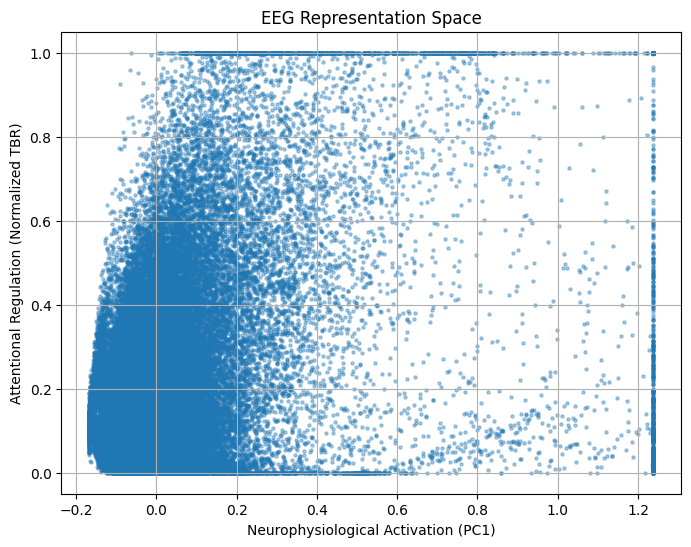

In [8]:
# ============================================================
# Step 7: EEG Representation Space
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    EEG_representation["Activation_PC1"],
    EEG_representation["Attention_TBR"],
    alpha=0.2,
    s=5
)

plt.xlabel("Neurophysiological Activation (PC1)")
plt.ylabel("Attentional Regulation (Normalized TBR)")
plt.title("EEG Representation Space")

plt.grid(True)

plt.show()

In [9]:
# ============================================================
# Step 8: Save EEG Representation & Processing Objects
# ============================================================

import joblib

EEG_representation.to_csv(
    "EEG_Representation.csv",
    index=False
)

joblib.dump(activity_pca, "eeg_activity_pca.pkl")
joblib.dump(scaler, "eeg_scaler.pkl")
joblib.dump(clip_values, "clip_thresholds.pkl")

print("EEG Representation Saved Successfully")

EEG Representation Saved Successfully


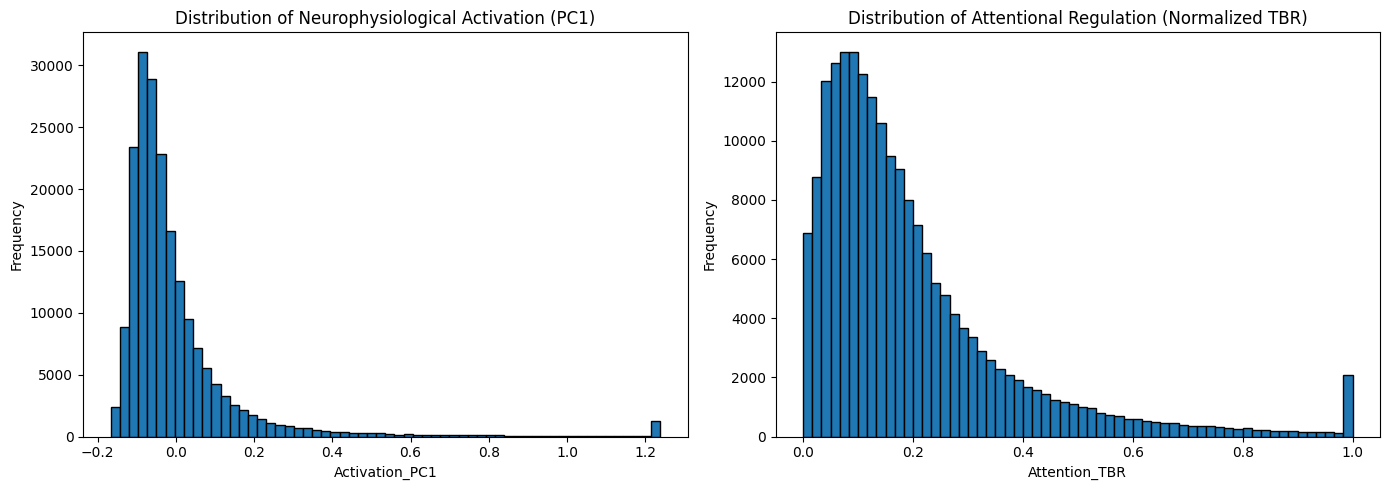

In [10]:
# ============================================================
# Step 9: Distribution of EEG Representations
# ============================================================

import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(14,5))

# Activation PC1
ax[0].hist(
    EEG_representation["Activation_PC1"],
    bins=60,
    edgecolor="black"
)

ax[0].set_title("Distribution of Neurophysiological Activation (PC1)")
ax[0].set_xlabel("Activation_PC1")
ax[0].set_ylabel("Frequency")

# Attention Representation
ax[1].hist(
    EEG_representation["Attention_TBR"],
    bins=60,
    edgecolor="black"
)

ax[1].set_title("Distribution of Attentional Regulation (Normalized TBR)")
ax[1].set_xlabel("Attention_TBR")
ax[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

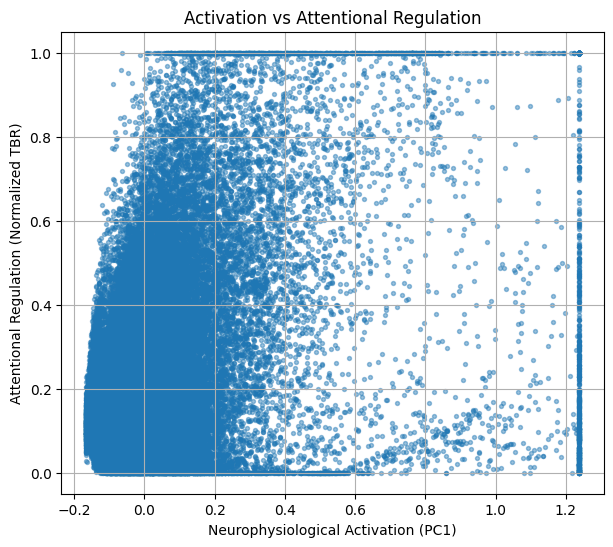

In [11]:
# ============================================================
# Step 10: Relationship Between EEG Representations
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))

plt.scatter(
    EEG_representation["Activation_PC1"],
    EEG_representation["Attention_TBR"],
    alpha=0.25,
    s=8
)

plt.xlabel("Neurophysiological Activation (PC1)")
plt.ylabel("Attentional Regulation (Normalized TBR)")
plt.title("Activation vs Attentional Regulation")

plt.grid(True)

plt.show()

In [12]:
# ============================================================
# Step 11: Correlation Between Latent Representations
# ============================================================

pearson = EEG_representation.corr(method="pearson")

spearman = EEG_representation.corr(method="spearman")

print("="*60)
print("Pearson Correlation")
print("="*60)

display(pearson)

print("\n")

print("="*60)
print("Spearman Correlation")
print("="*60)

display(spearman)

Pearson Correlation


,Activation_PC1,Attention_TBR
Activation_PC1,1.0000,0.4241
Attention_TBR,0.4241,1.0000




Spearman Correlation


,Activation_PC1,Attention_TBR
Activation_PC1,1.000000,0.333774
Attention_TBR,0.333774,1.000000


In [13]:
# ============================================================
# Step 12: EEG Representation Summary
# ============================================================

summary = EEG_representation.describe().T

summary["Skewness"] = EEG_representation.skew()

summary["Kurtosis"] = EEG_representation.kurtosis()

display(summary)

,count,mean,std,min,25%,50%,75%,max,Skewness,Kurtosis
Activation_PC1,195408.0,-7.272402e-18,0.171263,-0.166631,-0.085562,-0.046769,0.020339,1.237734,4.168129,22.800761
Attention_TBR,195408.0,1.985903e-01,0.183686,0.000000,0.077693,0.145153,0.252551,1.000000,2.041553,4.918267


In [14]:
# ============================================================
# Step 13: PCA Information Retention
# ============================================================

print("="*60)
print("PCA Validation")
print("="*60)

print(f"Explained Variance Ratio : {activity_pca.explained_variance_ratio_[0]:.4f}")

print(f"Information Retained     : {activity_pca.explained_variance_ratio_[0]*100:.2f}%")

print(f"Information Lost         : {(1-activity_pca.explained_variance_ratio_[0])*100:.2f}%")

PCA Validation
Explained Variance Ratio : 0.7715
Information Retained     : 77.15%
Information Lost         : 22.85%


In [15]:
# ============================================================
# Step 14: EEG Representation Validation Report
# ============================================================

print("="*70)
print("EEG REPRESENTATION VALIDATION")
print("="*70)

ev = activity_pca.explained_variance_ratio_[0]
corr = EEG_representation.corr().iloc[0,1]

print(f"PCA Explained Variance : {ev:.3f}")
print(f"Representation Correlation : {corr:.3f}")

print("\nInterpretation:")

if ev > 0.80:
    print("✓ Excellent latent representation of Theta and Beta.")
elif ev > 0.60:
    print("✓ Good latent representation with acceptable information retention.")
else:
    print("• Moderate representation. Theta and Beta retain complementary information.")

if abs(corr) < 0.30:
    print("✓ Activation and Attention capture complementary neurophysiological information.")
else:
    print("• Activation and Attention exhibit noticeable dependence.")

print("\nEEG Representation Ready for Multimodal Fusion.")
print("="*70)

EEG REPRESENTATION VALIDATION
PCA Explained Variance : 0.771
Representation Correlation : 0.424

Interpretation:
✓ Good latent representation with acceptable information retention.
• Activation and Attention exhibit noticeable dependence.

EEG Representation Ready for Multimodal Fusion.
